# 02 — Polytopes, Reachability, and Invariant Sets

## Geometry for constrained dynamical systems

A state constraint such as

$$
|p|\le 4,
\qquad
|v|\le 3
$$

is not merely a pair of limits. Together, the inequalities define a **set** in state space.

Once dynamics are introduced, the essential questions become geometric:

- Which states can be reached from a given set?
- Which states can reach a target set?
- Which states can remain safe forever?
- Which states remain safe under one fixed controller?
- Which states can remain safe if we are allowed to choose the input intelligently at every step?

For linear systems with linear inequalities, these questions naturally lead to
**polyhedra, polytopes, predecessor sets, reachable sets, and invariant sets**.

The central idea of this notebook is:

$$
\boxed{
\text{constraints}
+
\text{dynamics}
\quad\Longrightarrow\quad
\text{geometry in state space}.
}
$$


## Learning objectives

After completing this notebook, you should be able to:

1. distinguish a polyhedron from a polytope;
2. work with H- and V-representations;
3. explain why different representations are useful for different computations;
4. identify and remove redundant inequalities;
5. compute intersections, affine images, linear preimages, and Minkowski sums;
6. distinguish **forward reachable sets** from **backward predecessor sets**;
7. derive the controlled predecessor

$$
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
\{x\in\mathcal X:
\exists u\in\mathcal U,\;
Ax+Bu\in\mathcal S\};
$$

8. understand predecessor computation as a **projection problem**;
9. derive scalar-input predecessor inequalities by Fourier–Motzkin elimination;
10. build finite-step controllable sets;
11. distinguish positive invariance from control invariance;
12. compute maximal positively invariant and maximal control-invariant sets;
13. reason carefully about the quantifiers

$$
\forall x
\qquad\text{and}\qquad
\exists u;
$$

14. understand the computational difficulties that appear as dimension grows.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.linear import dlqr
from advanced_mpc_lmpc.polytopes import (
    HPolytope,
    affine_image_2d,
    minkowski_sum_2d,
    reachable_set_scalar_input_2d,
    linear_preimage,
    predecessor_scalar_input,
    maximal_invariant,
    maximal_control_invariant,
    closed_loop_admissible_set_scalar_input,
    n_step_controllable_sets,
)
from advanced_mpc_lmpc.plotting import plot_polytope

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — Polyhedral geometry](#part-1)** — I.1 Polyhedra and polytopes · I.2 Why keep both H and V representations? · I.3 Membership testing · I.4 Redundant inequalities
- **[Part II — Basic set operations](#part-2)** — II.1 Intersection · II.2 Affine images · II.3 Linear preimages · II.4 Minkowski sum · II.5 Projection and existential variables
- **[Part III — Reachability and predecessor sets](#part-3)** — III.1 Dynamical model · III.2 Forward reachable set · III.3 Controlled predecessor · III.4 Canonical predecessor construction by projection · III.5 Equivalent Minkowski-sum viewpoint · III.6 Exact scalar-input predecessor by Fourier–Motzkin elimination · III.7 Find an actual witness control
- **[Part IV — Finite-step controllability](#part-4)** — IV.1 Backward recursion to a target · IV.2 A minimum-step map · IV.3 Reachable versus controllable-to-target sets
- **[Part V — Invariance](#part-5)** — V.1 Positive invariance · V.2 Maximal positively invariant subset of a constraint set · V.3 A subtle but essential point: input constraints under a fixed feedback · V.4 Why the iteration removes states · V.5 Control invariance · V.6 Positive invariance versus control invariance · V.7 Maximal control-invariant subset · V.8 A control-invariant set gives a one-step feasibility certificate
- **[Part VI — Geometry of safety and feasibility](#part-6)** — VI.1 Target reachability and invariance are different concepts · VI.2 Constraint boundaries are not all equally dangerous · VI.3 Computing a safe action at a state
- **[Part VII — Numerical complexity and representation choices](#part-7)** — VII.1 Representation switching is not cosmetic · VII.2 Why exact set computations become expensive · VII.3 Numerical equality of polytopes
- **[Part VIII — Common conceptual pitfalls](#part-8)** — VIII.1 Pitfall: reachable set = predecessor set · VIII.2 Pitfall: $A^{-1}(\mathcal S)$ means matrix inversion · VIII.3 Pitfall: control invariance means one input works for the whole set · VIII.4 Pitfall: satisfying constraints now implies future safety · VIII.5 Pitfall: stable feedback automatically respects constraints · VIII.6 Pitfall: an invariant set is automatically robust
- **[Part IX — Check your understanding](#part-9)**
- **[Part X — Exercises](#part-10)**
- **[Part XI — Scope and references](#part-11)**


<a id="part-1"></a>
# Part I — Polyhedral geometry

## I.1 Polyhedra and polytopes

A **polyhedron** is the intersection of finitely many closed half-spaces:

$$
\mathcal P
=
\left\{
x\in\mathbb R^n:
Hx\le h
\right\}.
$$

A **polytope** is a bounded polyhedron.

Equivalently, every convex polytope can be described as the convex hull of finitely many vertices:

$$
\mathcal P
=
\operatorname{conv}
\{v_1,\ldots,v_M\}.
$$

This gives two important representations.

### H-representation

$$
\boxed{
\mathcal P
=
\{x:Hx\le h\}
}
$$

The letter H refers to **half-space representation**.

### V-representation

$$
\boxed{
\mathcal P
=
\operatorname{conv}\{v_1,\ldots,v_M\}.
}
$$

The letter V refers to **vertices**.


## I.2 Why keep both H and V representations?

The two descriptions encode the same set, but they are convenient for different operations.

### H-representation is natural for constraints

If

$$
|x_1|\le 4,
\qquad
|x_2|\le 3,
$$

then

$$
\begin{bmatrix}
1&0\\
-1&0\\
0&1\\
0&-1
\end{bmatrix}
x
\le
\begin{bmatrix}
4\\4\\3\\3
\end{bmatrix}.
$$

This is exactly the format used by optimization solvers.

### V-representation is natural for geometry

A convex combination

$$
x
=
\sum_{i=1}^M\lambda_i v_i,
\qquad
\lambda_i\ge0,
\qquad
\sum_i\lambda_i=1
$$

makes the geometry of the set explicit.

It is especially convenient for:

- plotting;
- convex combinations;
- Minkowski sums in low dimension.

The conversion is conceptually simple but can become computationally expensive in high dimension:

- H $\rightarrow$ V requires vertex enumeration;
- V $\rightarrow$ H requires a convex-hull / half-space computation.


H matrix:
[[ 0.89443  0.44721]
 [-0.97014  0.24254]
 [-0.15206  0.98837]
 [-0.19612 -0.98058]
 [ 0.60745 -0.79436]]

h vector:
[1.8783  1.69775 1.5966  1.37281 1.49526]

Vertices recovered from the H-representation:
[[ 2.2 -0.2]
 [ 1.2  1.8]
 [-1.4  1.4]
 [-2.  -1. ]
 [ 0.5 -1.5]]


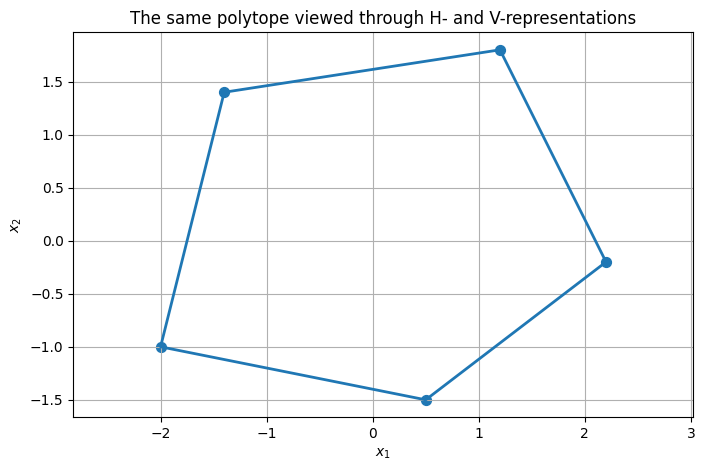

In [2]:
# A non-axis-aligned convex polygon given by its vertices.

V = np.array([
    [-2.0, -1.0],
    [ 0.5, -1.5],
    [ 2.2, -0.2],
    [ 1.2,  1.8],
    [-1.4,  1.4],
])

P = HPolytope.from_vertices_2d(V)

print("H matrix:")
print(P.H)
print("\nh vector:")
print(P.h)
print("\nVertices recovered from the H-representation:")
print(P.vertices_2d())

plt.figure()
ax = plt.gca()
plot_polytope(ax, P, linewidth=2)
verts = P.vertices_2d()
plt.scatter(verts[:, 0], verts[:, 1], s=50)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("The same polytope viewed through H- and V-representations")
plt.axis("equal")
plt.show()


## I.3 Membership testing

For an H-polytope

$$
\mathcal P=\{x:Hx\le h\},
$$

membership is immediate:

$$
x\in\mathcal P
\iff
Hx\le h
$$

componentwise.

This simple operation appears constantly:

- checking whether a simulated state is admissible;
- checking whether one set's vertices lie inside another set;
- verifying approximate convergence of iterative set algorithms.


In [3]:
test_points = np.array([
    [0.0, 0.0],
    [1.5, 0.0],
    [2.5, 1.5],
])

for x in test_points:
    print(f"{x} in P? {P.contains(x)}")


[0. 0.] in P? True
[1.5 0. ] in P? True
[2.5 1.5] in P? False


## I.4 Redundant inequalities

Suppose

$$
\mathcal P
=
\{x:Hx\le h\}.
$$

Some rows may be implied by the others.

For example,

$$
x_1\le1
$$

already implies

$$
x_1\le2.
$$

The second inequality does not change the set.

To test whether row $i$ is redundant, solve

$$
\max_x H_i x
$$

subject to all the other inequalities.

If the maximum satisfies

$$
\max H_i x\le h_i,
$$

then inequality $i$ is implied by the remaining rows and can be removed.

Redundancy reduction matters because repeated intersections and predecessor operations often
create many unnecessary half-spaces.


In [4]:
H_redundant = np.array([
    [ 1.0,  0.0],
    [-1.0,  0.0],
    [ 0.0,  1.0],
    [ 0.0, -1.0],
    [ 1.0,  0.0],  # weaker duplicate direction
])

h_redundant = np.array([1.0, 1.0, 1.0, 1.0, 2.0])

P_redundant = HPolytope(H_redundant, h_redundant)
P_reduced = P_redundant.remove_redundancy()

print("number of inequalities before reduction:", len(P_redundant.h))
print("number of inequalities after reduction :", len(P_reduced.h))
print("\nReduced H:")
print(P_reduced.H)
print("Reduced h:")
print(P_reduced.h)


number of inequalities before reduction: 5
number of inequalities after reduction : 4

Reduced H:
[[ 1.  0.]
 [-1.  0.]
 [ 0.  1.]
 [ 0. -1.]]
Reduced h:
[1. 1. 1. 1.]


<a id="part-2"></a>
# Part II — Basic set operations

## II.1 Intersection

If

$$
\mathcal P_1
=
\{x:H_1x\le h_1\}
$$

and

$$
\mathcal P_2
=
\{x:H_2x\le h_2\},
$$

then

$$
\boxed{
\mathcal P_1\cap\mathcal P_2
=
\left\{
x:
\begin{bmatrix}
H_1\\H_2
\end{bmatrix}x
\le
\begin{bmatrix}
h_1\\h_2
\end{bmatrix}
\right\}.
}
$$

In H-representation, intersection is therefore almost trivial:
**stack the inequalities**.

This is one reason H-representations are so natural in constrained control.


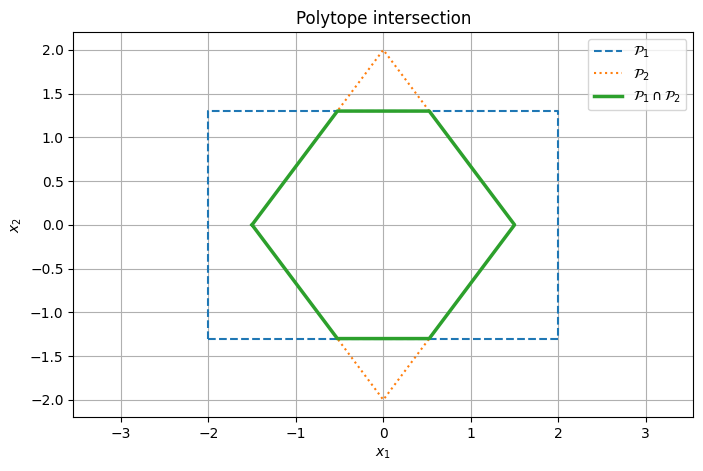

In [5]:
P1 = HPolytope.box([-2.0, -1.3], [2.0, 1.3])

P2 = HPolytope.from_vertices_2d(np.array([
    [-1.5,  0.0],
    [ 0.0, -2.0],
    [ 1.5,  0.0],
    [ 0.0,  2.0],
]))

Pint = P1.intersect(P2)

plt.figure()
ax = plt.gca()
plot_polytope(ax, P1, linestyle="--", label=r"$\mathcal{P}_1$")
plot_polytope(ax, P2, linestyle=":", label=r"$\mathcal{P}_2$")
plot_polytope(ax, Pint, linewidth=2.5, label=r"$\mathcal{P}_1\cap\mathcal{P}_2$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Polytope intersection")
plt.axis("equal")
plt.legend()
plt.show()


## II.2 Affine images

For a set $\mathcal X$, matrix $M$, and vector $c$,

$$
M\mathcal X+c
=
\{Mx+c:x\in\mathcal X\}.
$$

If $\mathcal X$ is a polytope, its affine image is again a polytope.

In V-representation this operation is immediate:

$$
\operatorname{conv}\{v_1,\ldots,v_M\}
\quad\mapsto\quad
\operatorname{conv}\{Mv_1+c,\ldots,Mv_M+c\}.
$$

This operation appears when propagating sets through linear dynamics.


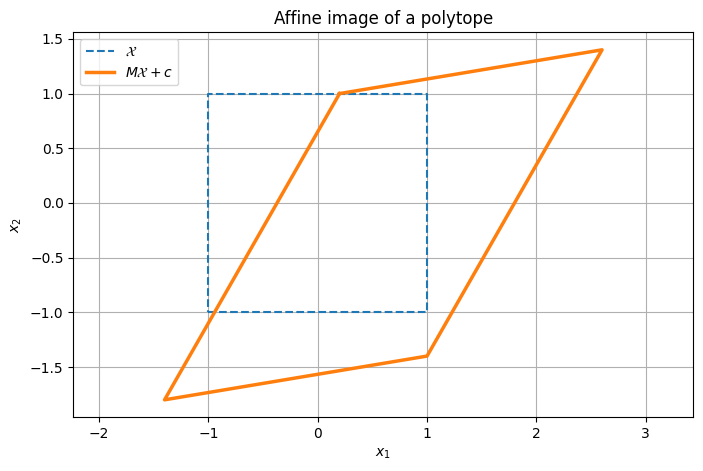

In [6]:
X_img = HPolytope.box([-1.0, -1.0], [1.0, 1.0])

M = np.array([
    [1.2, 0.8],
    [0.2, 1.4],
])
c = np.array([0.6, -0.2])

Y_img = affine_image_2d(X_img, M, c)

plt.figure()
ax = plt.gca()
plot_polytope(ax, X_img, linestyle="--", label=r"$\mathcal{X}$")
plot_polytope(ax, Y_img, linewidth=2.5, label=r"$M\mathcal{X}+c$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Affine image of a polytope")
plt.axis("equal")
plt.legend()
plt.show()


## II.3 Linear preimages

The **preimage** of a set $\mathcal S$ under the linear map $x\mapsto Ax$ is

$$
A^{-1}(\mathcal S)
=
\{x:Ax\in\mathcal S\}.
$$

This notation means **inverse image of a set**.
It does not require the matrix $A$ to be invertible.

If

$$
\mathcal S=\{y:H_Sy\le h_S\},
$$

then

$$
Ax\in\mathcal S
$$

is equivalent to

$$
H_SAx\le h_S.
$$

Therefore

$$
\boxed{
A^{-1}(\mathcal S)
=
\{x:(H_SA)x\le h_S\}.
}
$$

This is the basic autonomous predecessor operation.


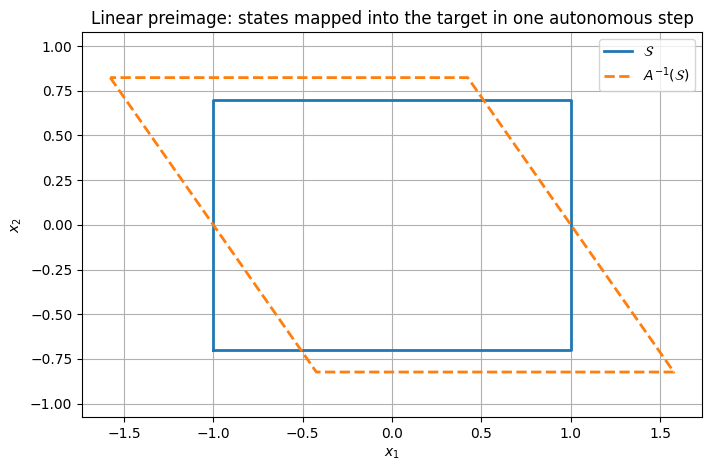

In [7]:
S_pre = HPolytope.box([-1.0, -0.7], [1.0, 0.7])

A_pre = np.array([
    [1.0, 0.7],
    [0.0, 0.85],
])

Pre_aut = linear_preimage(S_pre, A_pre)

plt.figure()
ax = plt.gca()
plot_polytope(ax, S_pre, linewidth=2, label=r"$\mathcal{S}$")
plot_polytope(ax, Pre_aut, linestyle="--", linewidth=2,
              label=r"$A^{-1}(\mathcal{S})$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Linear preimage: states mapped into the target in one autonomous step")
plt.axis("equal")
plt.legend()
plt.show()


## II.4 Minkowski sum

For two sets $\mathcal X,\mathcal Y\subseteq\mathbb R^n$,

$$
\boxed{
\mathcal X\oplus\mathcal Y
=
\{x+y:x\in\mathcal X,\;y\in\mathcal Y\}.
}
$$

For low-dimensional polytopes, a direct construction is:

1. enumerate vertices of $\mathcal X$;
2. enumerate vertices of $\mathcal Y$;
3. form all pairwise sums;
4. take the convex hull.

This is intuitive but scales poorly because the number of candidate vertex pairs grows rapidly.

Minkowski sums appear in:

- forward reachable sets;
- additive disturbance propagation;
- algebraic predecessor constructions.


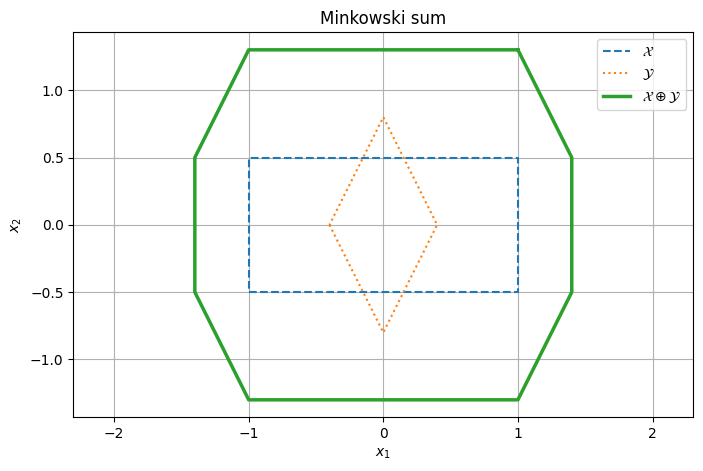

In [8]:
A_set = HPolytope.box([-1.0, -0.5], [1.0, 0.5])

B_set = HPolytope.from_vertices_2d(np.array([
    [-0.4,  0.0],
    [ 0.0, -0.8],
    [ 0.4,  0.0],
    [ 0.0,  0.8],
]))

Sum_set = minkowski_sum_2d(A_set, B_set)

plt.figure()
ax = plt.gca()
plot_polytope(ax, A_set, linestyle="--", label=r"$\mathcal{X}$")
plot_polytope(ax, B_set, linestyle=":", label=r"$\mathcal{Y}$")
plot_polytope(ax, Sum_set, linewidth=2.5, label=r"$\mathcal{X}\oplus\mathcal{Y}$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Minkowski sum")
plt.axis("equal")
plt.legend()
plt.show()


## II.5 Projection and existential variables

Projection is one of the most important ideas in set-based control.

Suppose a set is described in the augmented variable

$$
z=
\begin{bmatrix}
x\\u
\end{bmatrix}
$$

by

$$
\mathcal Z
=
\{(x,u):G_xx+G_uu\le g\}.
$$

The projection onto $x$ is

$$
\boxed{
\operatorname{Proj}_x(\mathcal Z)
=
\{x:\exists u\text{ such that }(x,u)\in\mathcal Z\}.
}
$$

The symbol $\exists u$ is exactly what makes projection relevant to control:

> keep the state $x$ if there exists at least one admissible control value $u$ that satisfies the
> required inequalities.

Projection is conceptually simple, but eliminating variables from a polyhedron can become
computationally expensive.


<a id="part-3"></a>
# Part III — Reachability and predecessor sets

## III.1 Dynamical model

Consider

$$
\boxed{
x^+=Ax+Bu,
}
$$

with

$$
x\in\mathcal X,
\qquad
u\in\mathcal U,
$$

where $\mathcal X$ and $\mathcal U$ are constrained sets.

There are two complementary geometric questions.

### Forward question

> Starting from a set $\mathcal S$, where can the system go in one step?

### Backward question

> From which states can the system reach $\mathcal S$ in one step?

The first gives a **reachable/post set**.
The second gives a **predecessor set**.


## III.2 Forward reachable set

For a set $\mathcal S$,

$$
\operatorname{Post}(\mathcal S)
=
\{Ax+Bu:x\in\mathcal S,\;u\in\mathcal U\}.
$$

Using set operations,

$$
\boxed{
\operatorname{Post}(\mathcal S)
=
A\mathcal S\oplus B\mathcal U.
}
$$

This is a forward propagation operation.


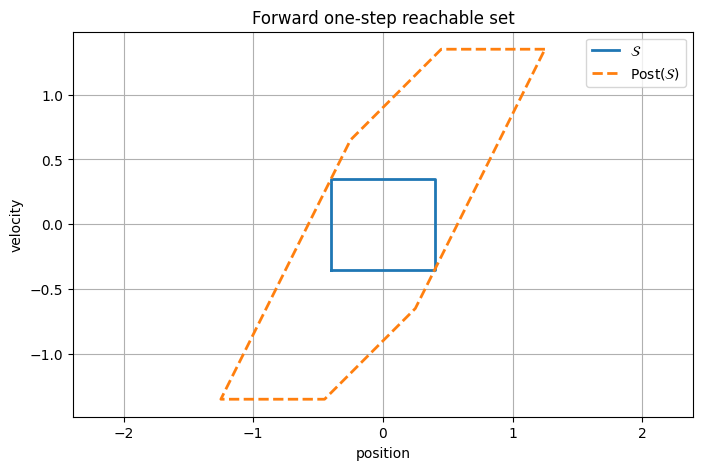

In [9]:
A = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
])

B = np.array([
    [0.5],
    [1.0],
])

umin, umax = -1.0, 1.0

S = HPolytope.box([-0.4, -0.35], [0.4, 0.35])

PostS = reachable_set_scalar_input_2d(S, A, B, umin, umax)

plt.figure()
ax = plt.gca()
plot_polytope(ax, S, linewidth=2, label=r"$\mathcal{S}$")
plot_polytope(ax, PostS, linewidth=2, linestyle="--",
              label=r"$\operatorname{Post}(\mathcal{S})$")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Forward one-step reachable set")
plt.axis("equal")
plt.legend()
plt.show()


## III.3 Controlled predecessor

Given a target set $\mathcal S$, define

$$
\boxed{
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
\left\{
x\in\mathcal X:
\exists u\in\mathcal U
\text{ such that }
Ax+Bu\in\mathcal S
\right\}.
}
$$

Read the quantifiers carefully:

$$
\forall x\in\operatorname{Pre}_{\mathcal U}(\mathcal S),
\quad
\exists u\in\mathcal U
$$

that sends that state into $\mathcal S$ in one step.

The admissible input can depend on $x$.

This is not the same statement as saying there exists one single input that works for every
state.


## III.4 Canonical predecessor construction by projection

Assume

$$
\mathcal S
=
\{y:H_Sy\le h_S\}.
$$

The condition

$$
Ax+Bu\in\mathcal S
$$

means

$$
H_SAx+H_SBu\le h_S.
$$

Now build the augmented set

$$
\mathcal Z
=
\left\{
(x,u):
\begin{array}{l}
H_SAx+H_SBu\le h_S,\\
x\in\mathcal X,\\
u\in\mathcal U
\end{array}
\right\}.
$$

Then

$$
\boxed{
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
\operatorname{Proj}_x(\mathcal Z).
}
$$

This is the definition-level construction:
**predecessor computation is fundamentally a projection problem**.


## III.5 Equivalent Minkowski-sum viewpoint

Starting from

$$
Ax+Bu\in\mathcal S,
$$

rewrite as

$$
Ax\in\mathcal S-Bu.
$$

Since $u$ may take any value in $\mathcal U$,

$$
Ax\in
\mathcal S\oplus(-B\mathcal U).
$$

Hence

$$
\boxed{
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
A^{-1}
\left(
\mathcal S\oplus(-B\mathcal U)
\right),
}
$$

where $A^{-1}(\cdot)$ means **set preimage**.

Geometrically:

1. enlarge the target by all admissible opposite control effects;
2. pull that enlarged set backward through the state dynamics.

The projection and Minkowski constructions describe the same geometric object.


## III.6 Exact scalar-input predecessor by Fourier–Motzkin elimination

The reusable code in this repository uses an explicit elimination argument for a scalar input.

Suppose the target condition and input bounds can be written as inequalities

$$
\alpha_i^\top x+\beta_i u\le\gamma_i.
$$

For $\beta_i>0$,

$$
u
\le
\frac{\gamma_i-\alpha_i^\top x}{\beta_i}.
$$

For $\beta_j<0$,

$$
u
\ge
\frac{\gamma_j-\alpha_j^\top x}{\beta_j}.
$$

For an admissible $u$ to exist, **every lower bound must be below every upper bound**.

Thus, for every pair with $\beta_j<0$ and $\beta_i>0$,

$$
\frac{\gamma_j-\alpha_j^\top x}{\beta_j}
\le
\frac{\gamma_i-\alpha_i^\top x}{\beta_i}.
$$

These pairwise inequalities eliminate $u$ and leave inequalities only in $x$.

Rows with $\beta=0$ are already direct state inequalities.

This is a special case of **Fourier–Motzkin elimination**, i.e. projection by eliminating an
inequality variable.


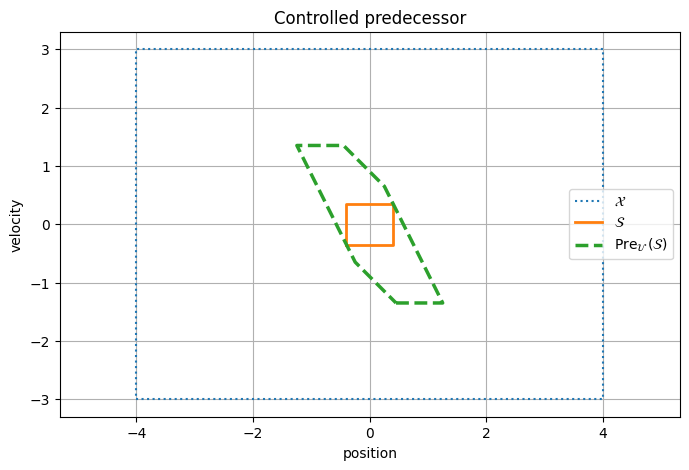

In [10]:
X = HPolytope.box([-4.0, -3.0], [4.0, 3.0])

PreS_unclipped = predecessor_scalar_input(S, A, B, umin, umax)
PreS = X.intersect(PreS_unclipped)

plt.figure()
ax = plt.gca()
plot_polytope(ax, X, linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, S, linewidth=2, label=r"$\mathcal{S}$")
plot_polytope(ax, PreS, linewidth=2.5, linestyle="--",
              label=r"$\operatorname{Pre}_{\mathcal{U}}(\mathcal{S})$")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Controlled predecessor")
plt.axis("equal")
plt.legend()
plt.show()


## III.7 Find an actual witness control

Membership in the predecessor means more than geometry:

$$
x\in\operatorname{Pre}_{\mathcal U}(\mathcal S)
$$

must imply that we can exhibit an input $u$ such that

$$
Ax+Bu\in\mathcal S.
$$

For a fixed $x$, finding such a control is a small feasibility problem:

$$
\begin{aligned}
\text{find}\quad &u\\
\text{s.t.}\quad
&H_S(Ax+Bu)\le h_S,\\
&u_{\min}\le u\le u_{\max}.
\end{aligned}
$$


In [11]:
def predecessor_witness_scalar(x, S, A, B, umin, umax):
    x = np.asarray(x, float)
    A = np.asarray(A, float)
    B = np.asarray(B, float).reshape(-1, 1)

    A_ub = S.H @ B
    b_ub = S.h - S.H @ A @ x

    res = linprog(
        c=np.zeros(1),
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=[(umin, umax)],
        method="highs",
    )
    if not res.success:
        return None
    return float(res.x[0])

# Choose a point from the predecessor but outside the target.
candidate = np.array([-0.65, 0.45])

print("candidate in target?     ", S.contains(candidate))
print("candidate in predecessor?", PreS.contains(candidate))

u_witness = predecessor_witness_scalar(candidate, S, A, B, umin, umax)
print("witness input:", u_witness)

if u_witness is not None:
    x_next = A @ candidate + B[:, 0] * u_witness
    print("next state:", x_next)
    print("next state in target?", S.contains(x_next))


candidate in target?      False
candidate in predecessor? True
witness input: -0.10000000000000003
next state: [-0.25  0.35]
next state in target? True


<a id="part-4"></a>
# Part IV — Finite-step controllability

## IV.1 Backward recursion to a target

Let

$$
\mathcal K_0=\mathcal S.
$$

Define recursively

$$
\boxed{
\mathcal K_{j+1}
=
\mathcal X
\cap
\operatorname{Pre}_{\mathcal U}(\mathcal K_j).
}
$$

Then:

- $\mathcal K_0$ is the target;
- $\mathcal K_1$ contains states that can reach the target in one admissible step;
- $\mathcal K_2$ contains states that can reach $\mathcal K_1$ in one step, hence the target in
at most two steps;
- and so on.

Under this recursion, $\mathcal K_N$ is an $N$-step controllable set to the target, subject to the
state/input constraints built into the predecessor construction.


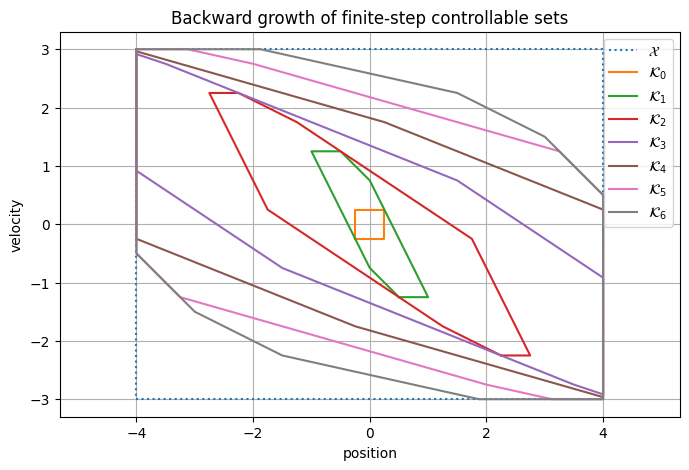

In [12]:
target = HPolytope.box([-0.25, -0.25], [0.25, 0.25])

Ksets = n_step_controllable_sets(
    A, B, X, target,
    umin=-1.0,
    umax=1.0,
    N=6,
)

plt.figure()
ax = plt.gca()
plot_polytope(ax, X, linestyle=":", linewidth=1.5, label=r"$\mathcal{X}$")

for j, Kj in enumerate(Ksets):
    plot_polytope(ax, Kj, linewidth=1.5, label=rf"$\mathcal{{K}}_{j}$")

plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Backward growth of finite-step controllable sets")
plt.axis("equal")
plt.legend()
plt.show()


## IV.2 A minimum-step map

The nested sets also encode a crude “distance in control steps” to the target.

For each state, define

$$
N_{\min}(x)
=
\min\{j:x\in\mathcal K_j\}.
$$

This is not a Euclidean distance.

Two points that are geometrically close can require different numbers of steps because of:

- dynamics;
- velocity;
- control saturation;
- state constraints.

The map therefore reflects the **physics of controllability**, not just geometric distance.


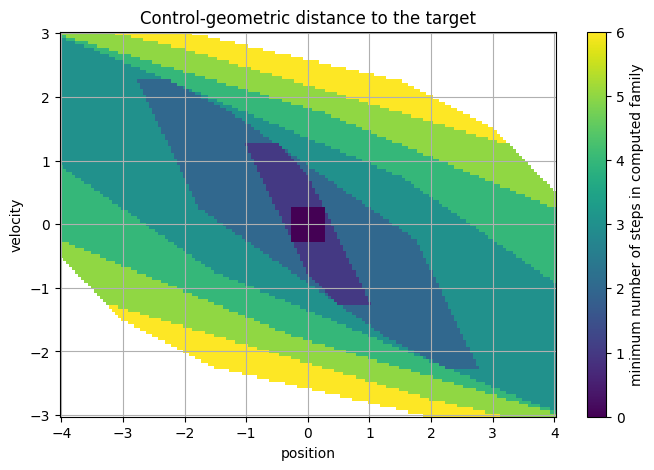

In [13]:
p_grid = np.linspace(-4.0, 4.0, 161)
v_grid = np.linspace(-3.0, 3.0, 121)

Nmin = np.full((len(v_grid), len(p_grid)), np.nan)

for iv, vv in enumerate(v_grid):
    for ip, pp in enumerate(p_grid):
        x = np.array([pp, vv])

        if not X.contains(x):
            continue

        for j, Kj in enumerate(Ksets):
            if Kj.contains(x):
                Nmin[iv, ip] = j
                break

plt.figure()
mesh = plt.pcolormesh(p_grid, v_grid, Nmin, shading="auto")
plt.colorbar(mesh, label="minimum number of steps in computed family")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Control-geometric distance to the target")
plt.show()


## IV.3 Reachable versus controllable-to-target sets

These are easy to confuse.

### Forward reachable set

Given an initial set $\mathcal X_0$,

$$
\mathcal R_1
=
A\mathcal X_0\oplus B\mathcal U.
$$

It answers:

> where can I go?

### Backward controllable/predecessor set

Given a target $\mathcal S$,

$$
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
\{x:\exists u,\;Ax+Bu\in\mathcal S\}.
$$

It answers:

> where can I start if I want to get there?

Forward and backward set propagation are dual viewpoints, but they are not the same set operation.


<a id="part-5"></a>
# Part V — Invariance

## V.1 Positive invariance

For the autonomous system

$$
x^+=A_{\mathrm{cl}}x,
$$

a set $\Omega$ is **positively invariant** if

$$
\boxed{
x\in\Omega
\Longrightarrow
A_{\mathrm{cl}}x\in\Omega.
}
$$

Equivalently,

$$
A_{\mathrm{cl}}\Omega\subseteq\Omega.
$$

Once a trajectory enters $\Omega$, the fixed autonomous dynamics keep it there forever.


## V.2 Maximal positively invariant subset of a constraint set

Suppose the state must remain in $\mathcal S$.

The maximal positively invariant subset can be characterized as

$$
\boxed{
\mathcal O_\infty(\mathcal S)
=
\bigcap_{k=0}^{\infty}
A_{\mathrm{cl}}^{-k}\mathcal S.
}
$$

Interpretation:

- $x\in\mathcal S$;
- after one step, $A_{\mathrm{cl}}x\in\mathcal S$;
- after two steps, $A_{\mathrm{cl}}^2x\in\mathcal S$;
- and so on forever.

A practical fixed-point iteration is

$$
\Omega_0=\mathcal S,
$$

$$
\boxed{
\Omega_{j+1}
=
\mathcal S
\cap
A_{\mathrm{cl}}^{-1}(\Omega_j).
}
$$

When

$$
\Omega_{j+1}=\Omega_j,
$$

the iteration has reached a fixed point.


## V.3 A subtle but essential point: input constraints under a fixed feedback

Suppose the controller is fixed as

$$
u=-Kx.
$$

Even if $x\in\mathcal X$, the feedback may violate the actuator bounds.

Therefore the admissible closed-loop state set is not just $\mathcal X$.

For scalar bounds

$$
u_{\min}\le -Kx\le u_{\max},
$$

define

$$
\boxed{
\mathcal X_K
=
\left\{
x\in\mathcal X:
u_{\min}\le -Kx\le u_{\max}
\right\}.
}
$$

The maximal invariant set for the fixed controller should be computed **inside $\mathcal X_K$**,
not merely inside the state box.


In [14]:
Q = np.diag([1.0, 0.2])
R = np.array([[0.2]])

K, P_lqr, eig_cl = dlqr(A, B, Q, R)
Acl = A - B @ K

print("LQR gain K:")
print(K)
print("closed-loop eigenvalues:")
print(eig_cl)

XK = closed_loop_admissible_set_scalar_input(
    X, K,
    umin=-1.0,
    umax=1.0,
)

Oinf, Ohistory = maximal_invariant(Acl, XK)

print("fixed-point iterations:", len(Ohistory) - 1)
print("number of vertices in O_inf:", len(Oinf.vertices_2d()))


LQR gain K:
[[0.7396 1.2604]]
closed-loop eigenvalues:
[0.1849+0.27425j 0.1849-0.27425j]
fixed-point iterations: 2
number of vertices in O_inf: 4


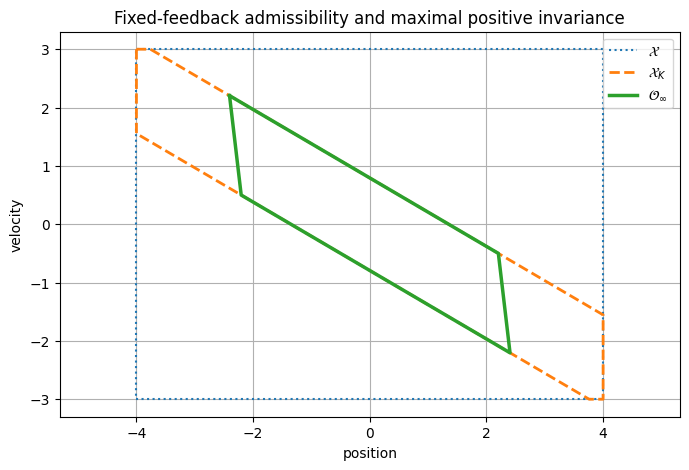

In [15]:
plt.figure()
ax = plt.gca()
plot_polytope(ax, X, linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, XK, linestyle="--", linewidth=2,
              label=r"$\mathcal{X}_K$")
plot_polytope(ax, Oinf, linewidth=2.5,
              label=r"$\mathcal{O}_\infty$")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Fixed-feedback admissibility and maximal positive invariance")
plt.axis("equal")
plt.legend()
plt.show()


## V.4 Why the iteration removes states

Start with all states satisfying the immediate constraints:

$$
\Omega_0=\mathcal X_K.
$$

Then

$$
\Omega_1
=
\mathcal X_K
\cap
A_{\mathrm{cl}}^{-1}(\Omega_0)
$$

removes states that are admissible **now** but leave the admissible set after one step.

Next,

$$
\Omega_2
$$

removes states that survive one step but fail later.

The process continues until no additional states need to be removed.

So the algorithm converts a **one-step constraint set** into an **infinite-time safe set for that
fixed closed-loop law**.


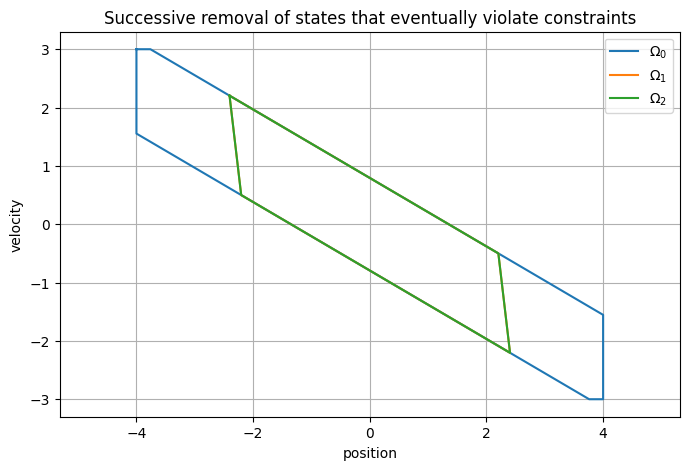

In [16]:
# Visualize several iterations of the fixed-feedback invariant-set computation.

plt.figure()
ax = plt.gca()

indices = sorted(set([0, 1, 2, min(4, len(Ohistory)-1), len(Ohistory)-1]))

for idx in indices:
    plot_polytope(
        ax,
        Ohistory[idx],
        linewidth=1.5,
        label=rf"$\Omega_{{{idx}}}$",
    )

plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Successive removal of states that eventually violate constraints")
plt.axis("equal")
plt.legend()
plt.show()


## V.5 Control invariance

Now return to

$$
x^+=Ax+Bu.
$$

A set $\mathcal C$ is **control invariant** if

$$
\boxed{
\forall x\in\mathcal C,
\quad
\exists u\in\mathcal U
\quad\text{such that}\quad
Ax+Bu\in\mathcal C.
}
$$

The order of quantifiers matters enormously:

$$
\forall x
\;\exists u.
$$

It says:

> for each state in the set, at least one admissible control action can keep the next state in
> the set.

The required input may be different at every state.


## V.6 Positive invariance versus control invariance

These concepts answer different questions.

### Positive invariant under a fixed controller

A specific law, for example

$$
u=-Kx,
$$

must keep every state in the set inside the set.

### Control invariant

We only require that **some** admissible input exists at each state.

Therefore a control-invariant set can generally be larger than the invariant set associated with
one particular feedback law.

A fixed controller commits to one action-selection rule.
Control invariance retains the freedom to choose the action state by state.


## V.7 Maximal control-invariant subset

Inside a state constraint set $\mathcal X$, initialize

$$
\mathcal C_0=\mathcal X.
$$

Then iterate

$$
\boxed{
\mathcal C_{j+1}
=
\mathcal X
\cap
\operatorname{Pre}_{\mathcal U}(\mathcal C_j).
}
$$

Interpretation:

- keep states that satisfy the state constraints now;
- also require the existence of an admissible input that sends them into the current candidate
safe set;
- repeat until reaching a fixed point.

At convergence, the result is the maximal control-invariant subset represented by this
fixed-point construction.


In [17]:
Cinf, Chistory = maximal_control_invariant(
    A, B, X,
    umin=-1.0,
    umax=1.0,
)

print("control-invariant fixed-point iterations:", len(Chistory) - 1)
print("number of vertices in C_inf:", len(Cinf.vertices_2d()))


control-invariant fixed-point iterations: 4
number of vertices in C_inf: 10


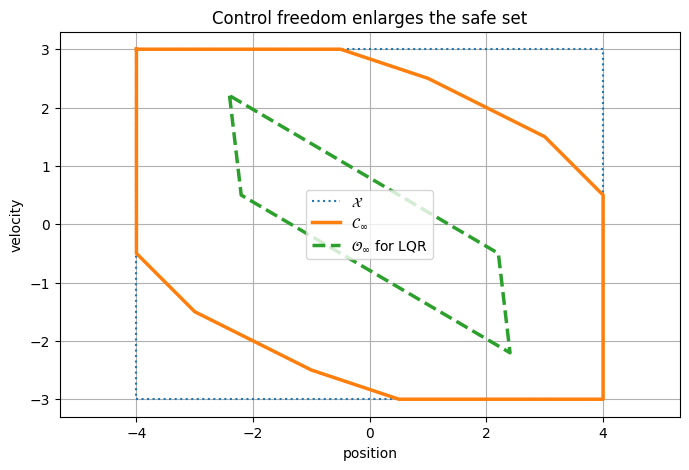

Every plotted O_inf vertex is contained in C_inf? True


In [18]:
plt.figure()
ax = plt.gca()
plot_polytope(ax, X, linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, Cinf, linewidth=2.5,
              label=r"$\mathcal{C}_\infty$")
plot_polytope(ax, Oinf, linewidth=2.5, linestyle="--",
              label=r"$\mathcal{O}_\infty$ for LQR")
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Control freedom enlarges the safe set")
plt.axis("equal")
plt.legend()
plt.show()

all_O_vertices_in_C = all(Cinf.contains(v, tol=1e-6)
                          for v in Oinf.vertices_2d())
print("Every plotted O_inf vertex is contained in C_inf?",
      all_O_vertices_in_C)


## V.8 A control-invariant set gives a one-step feasibility certificate

If

$$
x\in\mathcal C_\infty,
$$

then by definition there exists an admissible input such that

$$
x^+
=
Ax+Bu
\in
\mathcal C_\infty.
$$

Because the next state lies in the same control-invariant set, the argument can be repeated.

Thus the set provides a geometric certificate of **indefinite constraint maintainability**, under
the ideal nominal model used to compute it.

That last qualification matters: if the real dynamics differ from the model or disturbances are
present, nominal invariance alone does not automatically provide robustness.


<a id="part-6"></a>
# Part VI — Geometry of safety and feasibility

## VI.1 Target reachability and invariance are different concepts

A finite-step controllable set answers:

> Can I reach the target within a given number of steps?

An invariant set answers:

> Can I remain admissible forever?

A state can be:

- safe indefinitely but far from a desired target;
- able to reach the target quickly;
- immediately admissible but doomed to violate a constraint later;
- outside the safe kernel even though it satisfies all current constraints.

This is why set-based analysis contains more information than simply checking the current
state against a box constraint.


## VI.2 Constraint boundaries are not all equally dangerous

For the double integrator,

$$
x=
\begin{bmatrix}
p\\v
\end{bmatrix},
$$

consider two states with the same position:

$$
x^{(1)}
=
\begin{bmatrix}
3.8\\-1
\end{bmatrix},
\qquad
x^{(2)}
=
\begin{bmatrix}
3.8\\2.5
\end{bmatrix}.
$$

Geometrically they are equally close to the upper position boundary $p=4$.

Dynamically they are very different:

- the first is moving inward;
- the second is moving rapidly toward the boundary.

Invariant and predecessor sets encode this directionality automatically.


In [19]:
samples = [
    np.array([3.8, -1.0]),
    np.array([3.8,  2.5]),
    np.array([0.0,  2.8]),
    np.array([-3.5, -2.2]),
]

for x in samples:
    print(
        f"x={x}: "
        f"in X={X.contains(x)}, "
        f"in C_inf={Cinf.contains(x)}, "
        f"in O_inf(LQR)={Oinf.contains(x)}"
    )


x=[ 3.8 -1. ]: in X=True, in C_inf=True, in O_inf(LQR)=False
x=[3.8 2.5]: in X=True, in C_inf=False, in O_inf(LQR)=False
x=[0.  2.8]: in X=True, in C_inf=True, in O_inf(LQR)=False
x=[-3.5 -2.2]: in X=True, in C_inf=False, in O_inf(LQR)=False


## VI.3 Computing a safe action at a state

Control invariance says that an admissible action exists, but the set alone does not tell us which
one unless we solve a feasibility/optimization problem.

For a given $x\in\mathcal C_\infty$, one simple policy is:

$$
\min_u u^2
$$

subject to

$$
Ax+Bu\in\mathcal C_\infty,
\qquad
u_{\min}\le u\le u_{\max}.
$$

This selects the smallest-magnitude input that keeps the next state inside the safe set.

The invariant set supplies the feasibility guarantee;
the secondary objective chooses among safe actions.


In [20]:
def minimum_effort_safe_input(x, C, A, B, umin, umax):
    x = np.asarray(x, float)
    Bc = np.asarray(B, float).reshape(-1, 1)

    # C.H (A x + B u) <= C.h
    Aub = C.H @ Bc
    bub = C.h - C.H @ A @ x

    # Since this is scalar, solve by obtaining the feasible interval
    # from all linear inequalities, then project u=0 onto it.
    lower = float(umin)
    upper = float(umax)

    for a, b in zip(Aub.ravel(), bub):
        if abs(a) < 1e-12:
            if b < 0:
                return None
        elif a > 0:
            upper = min(upper, b / a)
        else:
            lower = max(lower, b / a)

    if lower > upper:
        return None

    return float(np.clip(0.0, lower, upper))

x_safe = np.array([3.0, 0.8])

print("state in C_inf?", Cinf.contains(x_safe))

u_safe = minimum_effort_safe_input(
    x_safe, Cinf, A, B,
    umin=-1.0,
    umax=1.0,
)

print("minimum-effort safe input:", u_safe)

if u_safe is not None:
    x_next = A @ x_safe + B[:, 0] * u_safe
    print("next state:", x_next)
    print("next state in C_inf?", Cinf.contains(x_next))


state in C_inf? True
minimum-effort safe input: -0.06666666666666643
next state: [3.76667 0.73333]
next state in C_inf? True


<a id="part-7"></a>
# Part VII — Numerical complexity and representation choices

## VII.1 Representation switching is not cosmetic

Different operations naturally favor different forms.

| Operation | Convenient representation |
|---|---|
| membership test | H |
| linear inequalities / constraints | H |
| intersection | H |
| autonomous preimage | H |
| plotting in low dimension | V |
| affine image in low dimension | V |
| Minkowski sum in low dimension | V |
| projection | depends on algorithm |
| convex combinations | V |

A practical set-based algorithm often switches repeatedly between H and V representations.

That conversion can dominate the cost.


## VII.2 Why exact set computations become expensive

Several mechanisms cause combinatorial growth.

### Vertex enumeration

A polytope may have many vertices even if its H-representation is compact.

### Facet growth

Intersections and elimination can generate many inequalities.

### Minkowski sums

A naive V-representation construction considers all vertex pairs:

$$
N_{\mathcal X}N_{\mathcal Y}
$$

before removing interior points.

### Projection

Eliminating variables can generate many new inequalities.
Fourier–Motzkin elimination is especially prone to this growth.

### Repeated set recursion

Reachability and invariant-set algorithms apply these operations many times.

Therefore exact explicit polytopes are excellent teaching tools and practical for many
low-dimensional systems, but higher-dimensional control problems often require specialized,
implicit, approximate, or optimization-based representations.


## VII.3 Numerical equality of polytopes

Two H-representations can describe exactly the same set while having completely different rows.

For example, one representation may contain:

- scaled duplicate inequalities;
- redundant facets;
- a different ordering of half-spaces.

Therefore comparing matrices directly,

$$
H_1\stackrel{?}{=}H_2,
$$

is not a reliable set-equality test.

In two dimensions, the repository checks approximate equality geometrically:

1. compute vertices of the first set;
2. check that all belong to the second;
3. compute vertices of the second;
4. check that all belong to the first.

For large-dimensional problems, more sophisticated containment tests are used.


<a id="part-8"></a>
# Part VIII — Common conceptual pitfalls

## VIII.1 Pitfall: reachable set = predecessor set

No.

$$
\operatorname{Post}(\mathcal S)
$$

propagates **forward** from $\mathcal S$.

$$
\operatorname{Pre}_{\mathcal U}(\mathcal S)
$$

works **backward** from a target $\mathcal S$.

---

## VIII.2 Pitfall: $A^{-1}(\mathcal S)$ means matrix inversion

Not necessarily.

Here

$$
A^{-1}(\mathcal S)
=
\{x:Ax\in\mathcal S\}
$$

means a set preimage.

---

## VIII.3 Pitfall: control invariance means one input works for the whole set

No.

The statement is

$$
\forall x\in\mathcal C,\;\exists u\in\mathcal U.
$$

The control may depend on the state.

---

## VIII.4 Pitfall: satisfying constraints now implies future safety

No.

A state may belong to $\mathcal X$ but lie outside $\mathcal C_\infty$.
It is admissible now but may have no admissible strategy that preserves constraints forever.

---

## VIII.5 Pitfall: stable feedback automatically respects constraints

No.

A stabilizing gain $K$ can command

$$
u=-Kx
$$

outside the actuator limits.
Input admissibility must be included when constructing the fixed-controller invariant set.

---

## VIII.6 Pitfall: an invariant set is automatically robust

Not unless uncertainty/disturbance assumptions are explicitly incorporated into the set
construction.

The invariant sets computed here are nominal sets for the specified dynamics.


<a id="part-9"></a>
# Part IX — Check your understanding

Try to answer these without looking back.

### Q1. What is the difference between a polyhedron and a polytope?

<details><summary>Answer</summary>

A polyhedron is an intersection of finitely many half-spaces and may be unbounded.
A polytope is a bounded polyhedron; equivalently, it is the convex hull of finitely many vertices.

</details>

### Q2. Why is H-representation convenient in constrained control?

<details><summary>Answer</summary>

Because state and input constraints are naturally linear inequalities, intersections are obtained
by stacking rows, and membership tests reduce to evaluating $Hx\le h$.

</details>

### Q3. Define the controlled predecessor precisely.

<details><summary>Answer</summary>

$$
\operatorname{Pre}_{\mathcal U}(\mathcal S)
=
\{x\in\mathcal X:\exists u\in\mathcal U,\;Ax+Bu\in\mathcal S\}.
$$

</details>

### Q4. Why is predecessor computation a projection problem?

<details><summary>Answer</summary>

Because we first construct the feasible augmented set of state-input pairs $(x,u)$ satisfying
the target and admissibility conditions, then keep exactly those states for which at least one
such input exists. Eliminating $u$ is projection onto the $x$ coordinates.

</details>

### Q5. Explain the Minkowski interpretation of the predecessor.

<details><summary>Answer</summary>

The existence of some $u\in\mathcal U$ with $Ax+Bu\in\mathcal S$ is equivalent to
$Ax\in\mathcal S\oplus(-B\mathcal U)$.
Taking the preimage through $A$ (and intersecting with $\mathcal X$) gives the predecessor.

</details>

### Q6. What does the $N$-step controllable set mean?

<details><summary>Answer</summary>

It contains states for which an admissible sequence can reach the target within the backward
recursion horizon while respecting the constraints encoded in the construction.

</details>

### Q7. Define positive invariance.

<details><summary>Answer</summary>

For $x^+=A_{\rm cl}x$, a set $\Omega$ is positively invariant if
$x\in\Omega$ implies $A_{\rm cl}x\in\Omega$.

</details>

### Q8. Define control invariance and state the quantifiers.

<details><summary>Answer</summary>

For every state $x$ in the set, there exists at least one admissible input $u$ that sends the
next state back into the set:

$$
\forall x\in\mathcal C,\;\exists u\in\mathcal U:
Ax+Bu\in\mathcal C.
$$

</details>

### Q9. Why is a maximal control-invariant set usually larger than the invariant set of one fixed controller?

<details><summary>Answer</summary>

Control invariance may choose a different admissible input at every state.
A fixed controller commits to a specific action-selection law and therefore has less freedom.

</details>

### Q10. Why must input constraints be included when computing a closed-loop invariant set?

<details><summary>Answer</summary>

A state trajectory may remain inside the state constraints while the chosen feedback law demands
an inadmissible actuator command. The admissible closed-loop set must enforce both state and
input constraints.

</details>

### Q11. Why can exact polytope calculations become expensive?

<details><summary>Answer</summary>

Vertex/facet counts can grow rapidly under conversion, Minkowski sums, projection, and repeated
set recursion. Variable elimination can generate many redundant inequalities.

</details>

### Q12. What does membership in a control-invariant set certify?

<details><summary>Answer</summary>

Under the nominal model and specified constraints, it certifies the existence of an admissible
control action that keeps the next state in the same set, so the argument can be repeated
indefinitely.

</details>


<a id="part-10"></a>
# Part X — Exercises

### Exercise 1 — H-representation

Write

$$
-2\le x_1\le3,
\qquad
-1\le x_2\le4
$$

as

$$
Hx\le h.
$$

---

### Exercise 2 — Redundant facet

Add the constraint

$$
x_1\le5
$$

to the previous set.

Prove that it is redundant by solving the corresponding LP conceptually.

---

### Exercise 3 — Affine image

Let

$$
M=
\begin{bmatrix}
1&1\\
0&2
\end{bmatrix}
$$

and let $\mathcal X$ be the unit square.

Compute the transformed vertices of $M\mathcal X$.

---

### Exercise 4 — Minkowski sum

For intervals

$$
\mathcal A=[-2,1],
\qquad
\mathcal B=[-1,3],
$$

compute

$$
\mathcal A\oplus\mathcal B.
$$

Then generalize the logic to axis-aligned boxes.

---

### Exercise 5 — Autonomous preimage

If

$$
\mathcal S=\{x:H_Sx\le h_S\}
$$

and

$$
x^+=Ax,
$$

derive the H-representation of

$$
\operatorname{Pre}(\mathcal S).
$$

---

### Exercise 6 — Fourier–Motzkin elimination

Start with

$$
\alpha_1^\top x+2u\le\gamma_1,
$$

$$
\alpha_2^\top x-u\le\gamma_2.
$$

Eliminate $u$ and derive one inequality involving only $x$.

---

### Exercise 7 — Quantifiers

Explain the difference between

$$
\forall x\in\mathcal C,\;\exists u\in\mathcal U
$$

and

$$
\exists u\in\mathcal U,\;\forall x\in\mathcal C.
$$

Which one defines control invariance?

---

### Exercise 8 — Fixed feedback

For a scalar-input law

$$
u=-Kx
$$

with

$$
|u|\le1,
$$

derive the two half-space inequalities defining the input-admissible state region.

---

### Exercise 9 — Invariant-set recursion

Starting with

$$
\Omega_0=\mathcal S,
$$

explain why

$$
\Omega_1
=
\mathcal S\cap A^{-1}(\mathcal S)
$$

contains exactly the states that satisfy the constraint at times $0$ and $1$.

Extend the interpretation to $\Omega_2$.

---

### Exercise 10 — Numerical experiment

Change the input limit from

$$
|u|\le1
$$

to

$$
|u|\le0.4.
$$

Recompute:

- finite-step controllable sets;
- $\mathcal C_\infty$;
- the fixed-LQR invariant set.

Explain the geometric changes.


<a id="part-11"></a>
# Part XI — Scope and references

**Scope.** This notebook covers the set computations behind constrained linear control: H- and
V-representations of polytopes, redundancy removal, intersections, affine images, preimages,
Minkowski sums and projection; forward reachable sets and controlled predecessor sets; finite-step
controllable sets; and maximal positively invariant and control-invariant sets, read as feasibility
certificates. All computations are exact and nominal (no disturbances), and the examples are
two-dimensional with a scalar input so that every set can be plotted. Robust invariance and
high-dimensional set computation are outside its scope.

**References.**

- F. Borrelli, A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*,
  Cambridge University Press, 2017: polyhedra, reachability and invariant sets for constrained control.
- F. Blanchini and S. Miani, *Set-Theoretic Methods in Control*, 2nd ed., Birkhäuser, 2015.
- E. G. Gilbert and K. T. Tan, "Linear systems with state and control constraints: The theory and
  application of maximal output admissible sets", *IEEE Transactions on Automatic Control*, 36(9),
  1008–1020, 1991: the fixed-point computation of maximal positively invariant sets.
- A. Schrijver, *Theory of Linear and Integer Programming*, Wiley, 1986: the equivalence of H- and
  V-representations (Minkowski–Weyl) and Fourier–Motzkin elimination.
- S. Boyd and L. Vandenberghe, *Convex Optimization*, Cambridge University Press, 2004: convex sets
  and the operations that preserve convexity.
